### Scalable E-Commerce Analytics and Demand Prediction

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("Big Data/olist_orders_dataset.csv")
items = pd.read_csv("Big Data/olist_order_items_dataset.csv")
products = pd.read_csv("Big Data/olist_products_dataset.csv")
customers = pd.read_csv("Big Data/olist_customers_dataset.csv")
sellers = pd.read_csv("Big Data/olist_sellers_dataset.csv")
payments = pd.read_csv("Big Data/olist_order_payments_dataset.csv")

In [3]:
print("Orders:", orders.shape)
print("Order Items:", items.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)
print("Payments:", payments.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Sellers: (3095, 4)
Payments: (103886, 5)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [9]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [10]:
print("==== MISSING VALUES ====")

print("\nORDERS")
print(orders.isnull().sum())

print("\nORDER ITEMS")
print(items.isnull().sum())

print("\nPRODUCTS")
print(products.isnull().sum())

print("\nCUSTOMERS")
print(customers.isnull().sum())

print("\nSELLERS")
print(sellers.isnull().sum())

print("\nPAYMENTS")
print(payments.isnull().sum())

==== MISSING VALUES ====

ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

ORDER ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

PRODUCTS
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city      

In [11]:
print("==== DUPLICATES ====")

print("Orders:", orders.duplicated().sum())
print("Order Items:", items.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Customers:", customers.duplicated().sum())
print("Sellers:", sellers.duplicated().sum())
print("Payments:", payments.duplicated().sum())

==== DUPLICATES ====
Orders: 0
Order Items: 0
Products: 0
Customers: 0
Sellers: 0
Payments: 0


In [12]:
print("==== UNIQUE IDs ====")

print("Orders:", orders["order_id"].nunique())
print("Customers:", customers["customer_id"].nunique())
print("Products:", products["product_id"].nunique())
print("Sellers:", sellers["seller_id"].nunique())

==== UNIQUE IDs ====
Orders: 99441
Customers: 99441
Products: 32951
Sellers: 3095


In [13]:
print("Orders rows:", len(orders))
print("Unique order IDs:", orders["order_id"].nunique())

print("Customers rows:", len(customers))
print("Unique customer IDs:", customers["customer_id"].nunique())

print("Products rows:", len(products))
print("Unique product IDs:", products["product_id"].nunique())

print("Sellers rows:", len(sellers))
print("Unique seller IDs:", sellers["seller_id"].nunique())

Orders rows: 99441
Unique order IDs: 99441
Customers rows: 99441
Unique customer IDs: 99441
Products rows: 32951
Unique product IDs: 32951
Sellers rows: 3095
Unique seller IDs: 3095


In [14]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
products["product_category_name"].value_counts().head(20)

product_category_name
cama_mesa_banho                      3029
esporte_lazer                        2867
moveis_decoracao                     2657
beleza_saude                         2444
utilidades_domesticas                2335
automotivo                           1900
informatica_acessorios               1639
brinquedos                           1411
relogios_presentes                   1329
telefonia                            1134
bebes                                 919
perfumaria                            868
papelaria                             849
fashion_bolsas_e_acessorios           849
cool_stuff                            789
ferramentas_jardim                    753
pet_shop                              719
eletronicos                           517
construcao_ferramentas_construcao     400
eletrodomesticos                      370
Name: count, dtype: int64

In [16]:
products["product_category_name"].isnull().sum()

np.int64(610)

In [17]:
items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [18]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [19]:
print("Minimum date:",
      orders["order_purchase_timestamp"].min())

print("Maximum date:",
      orders["order_purchase_timestamp"].max())

Minimum date: 2016-09-04 21:15:19
Maximum date: 2018-10-17 17:30:18


In [20]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [21]:
customers["customer_city"].nunique()

4119

In [22]:
# Missing value percentage for every dataset

def missing_summary(df, name):
    missing = df.isnull().sum()
    percentage = (missing / len(df)) * 100
    
    summary = pd.DataFrame({
        "Missing_Count": missing,
        "Missing_Percentage": percentage.round(2)
    })
    
    print(f"\n==== {name} ====")
    print(summary[summary["Missing_Count"] > 0])


missing_summary(orders, "ORDERS")
missing_summary(items, "ORDER ITEMS")
missing_summary(products, "PRODUCTS")
missing_summary(customers, "CUSTOMERS")
missing_summary(sellers, "SELLERS")
missing_summary(payments, "PAYMENTS")


==== ORDERS ====
                               Missing_Count  Missing_Percentage
order_approved_at                        160                0.16
order_delivered_carrier_date            1783                1.79
order_delivered_customer_date           2965                2.98

==== ORDER ITEMS ====
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []

==== PRODUCTS ====
                            Missing_Count  Missing_Percentage
product_category_name                 610                1.85
product_name_lenght                   610                1.85
product_description_lenght            610                1.85
product_photos_qty                    610                1.85
product_weight_g                        2                0.01
product_length_cm                       2                0.01
product_height_cm                       2                0.01
product_width_cm                        2                0.01

==== CUSTOMERS ====
Empty DataFrame
Columns: [Mis

In [23]:
# Compare missing delivery information with order status

orders.groupby("order_status").agg(
    total_orders=("order_id", "count"),
    missing_approved=("order_approved_at", lambda x: x.isna().sum()),
    missing_carrier_date=("order_delivered_carrier_date", lambda x: x.isna().sum()),
    missing_customer_date=("order_delivered_customer_date", lambda x: x.isna().sum())
)

,total_orders,missing_approved,missing_carrier_date,missing_customer_date
order_status,,,,
approved,2,0,2,2
canceled,625,141,550,619
created,5,5,5,5
delivered,96478,14,2,8
invoiced,314,0,314,314
processing,301,0,301,301
shipped,1107,0,0,1107
unavailable,609,0,609,609


In [24]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
]

print("Total delivered orders:", len(delivered_orders))

print(
    "Delivered orders with missing customer delivery date:",
    delivered_orders["order_delivered_customer_date"].isnull().sum()
)

print(
    "Delivered orders with missing carrier date:",
    delivered_orders["order_delivered_carrier_date"].isnull().sum()
)

Total delivered orders: 96478
Delivered orders with missing customer delivery date: 8
Delivered orders with missing carrier date: 2


In [25]:
print("Negative prices:")
print((items["price"] < 0).sum())

print("\nZero prices:")
print((items["price"] == 0).sum())

print("\nNegative freight:")
print((items["freight_value"] < 0).sum())

Negative prices:
0

Zero prices:
0

Negative freight:
0


In [26]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [27]:
print(
    "Negative payment values:",
    (payments["payment_value"] < 0).sum()
)

print(
    "Zero payment values:",
    (payments["payment_value"] == 0).sum()
)

Negative payment values: 0
Zero payment values: 9


In [28]:
# Check order IDs in order_items that don't exist in orders

missing_orders_in_items = ~items["order_id"].isin(
    orders["order_id"]
)

print(
    "Order items with unmatched order_id:",
    missing_orders_in_items.sum()
)

Order items with unmatched order_id: 0


In [29]:
missing_products_in_items = ~items["product_id"].isin(
    products["product_id"]
)

print(
    "Order items with unmatched product_id:",
    missing_products_in_items.sum()
)

Order items with unmatched product_id: 0


In [30]:
missing_sellers_in_items = ~items["seller_id"].isin(
    sellers["seller_id"]
)

print(
    "Order items with unmatched seller_id:",
    missing_sellers_in_items.sum()
)

Order items with unmatched seller_id: 0


In [31]:
missing_customers_in_orders = ~orders["customer_id"].isin(
    customers["customer_id"]
)

print(
    "Orders with unmatched customer_id:",
    missing_customers_in_orders.sum()
)

Orders with unmatched customer_id: 0


In [32]:
items_per_order = items.groupby(
    "order_id"
).size()

items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

In [33]:
print(
    "Maximum items in a single order:",
    items_per_order.max()
)
items_per_order.head(10)

Maximum items in a single order: 21


order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00024acbcdf0a6daa1e931b038114c75    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
00048cc3ae777c65dbb7d2a0634bc1ea    1
00054e8431b9d7675808bcb819fb4a32    1
000576fe39319847cbb9d288c5617fa6    1
0005a1a1728c9d785b8e2b08b904576c    1
0005f50442cb953dcd1d21e1fb923495    1
dtype: int64

In [34]:
payments_per_order = payments.groupby(
    "order_id"
).size()

payments_per_order.describe()

print(
    "Orders with multiple payment records:",
    (payments_per_order > 1).sum()
)

Orders with multiple payment records: 2961


In [35]:
category_translation = pd.read_csv("Big Data/product_category_name_translation.csv")

In [36]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [37]:
category_translation.shape

(71, 2)

In [38]:
category_translation.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [39]:
# Find orders that do not have any order-item records

orders_with_items = items["order_id"].unique()

orders_without_items = orders[
    ~orders["order_id"].isin(orders_with_items)
]

print("Total orders:", len(orders))
print("Orders with items:", len(orders_with_items))
print("Orders without items:", len(orders_without_items))

Total orders: 99441
Orders with items: 98666
Orders without items: 775


In [40]:
orders_without_items["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [41]:
orders_without_items_payment = orders_without_items[
    "order_id"
].isin(payments["order_id"])

print(
    "Orders without items but with payment records:",
    orders_without_items_payment.sum()
)

print(
    "Orders without items and without payment records:",
    (~orders_without_items_payment).sum()
)

Orders without items but with payment records: 775
Orders without items and without payment records: 0


In [42]:
orders_with_payments = payments["order_id"].unique()

orders_without_payments = orders[
    ~orders["order_id"].isin(orders_with_payments)
]

print(
    "Orders without payment records:",
    len(orders_without_payments)
)

print("\nStatus of orders without payments:")
print(
    orders_without_payments["order_status"].value_counts()
)

Orders without payment records: 1

Status of orders without payments:
order_status
delivered    1
Name: count, dtype: int64


In [43]:
print(payments["payment_type"].value_counts())

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [44]:
print(
    payments.groupby("payment_type")["payment_value"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

              count          sum        mean
payment_type                                
credit_card   76795  12542084.19  163.319021
boleto        19784   2869361.27  145.034435
voucher        5775    379436.87   65.703354
debit_card     1529    217989.79  142.570170
not_defined       3         0.00    0.000000


In [45]:
zero_payments = payments[
    payments["payment_value"] == 0
]

zero_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [46]:
zero_payments["payment_type"].value_counts()

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

In [47]:
zero_payments["order_id"].isin(
    orders["order_id"]
).value_counts()

order_id
True    9
Name: count, dtype: int64

In [48]:
missing_category_products = products[
    products["product_category_name"].isnull()
]

print(
    "Products with missing category:",
    len(missing_category_products)
)

print(
    "Products with missing name length:",
    missing_category_products[
        "product_name_lenght"
    ].isnull().sum()
)

print(
    "Products with missing description length:",
    missing_category_products[
        "product_description_lenght"
    ].isnull().sum()
)

print(
    "Products with missing photos:",
    missing_category_products[
        "product_photos_qty"
    ].isnull().sum()
)

Products with missing category: 610
Products with missing name length: 610
Products with missing description length: 610
Products with missing photos: 610


In [49]:
missing_category_products_sold = missing_category_products[
    "product_id"
].isin(items["product_id"])

print(
    "Missing-category products appearing in order items:",
    missing_category_products_sold.sum()
)

Missing-category products appearing in order items: 610


In [50]:
products[
    products["product_weight_g"].isnull() |
    products["product_length_cm"].isnull() |
    products["product_height_cm"].isnull() |
    products["product_width_cm"].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
print(
    "Products with missing physical dimensions:",
    products[
        products["product_weight_g"].isnull() |
        products["product_length_cm"].isnull() |
        products["product_height_cm"].isnull() |
        products["product_width_cm"].isnull()
    ].shape[0]
)

Products with missing physical dimensions: 2


In [52]:
orders["order_year"] = orders[
    "order_purchase_timestamp"
].dt.year

orders["order_month"] = orders[
    "order_purchase_timestamp"
].dt.month

print(
    orders["order_year"].value_counts().sort_index()
)

order_year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64


In [53]:
monthly_orders = (
    orders.groupby(
        orders["order_purchase_timestamp"].dt.to_period("M")
    )
    .size()
)

monthly_orders

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

In [54]:
print(
    "Number of months:",
    orders["order_purchase_timestamp"].dt.to_period("M").nunique()
)

Number of months: 25


In [55]:
# Create copies of the raw datasets for cleaning

orders_clean = orders.copy()
items_clean = items.copy()
products_clean = products.copy()
customers_clean = customers.copy()
sellers_clean = sellers.copy()
payments_clean = payments.copy()
category_translation_clean = category_translation.copy()

print("Clean copies created successfully.")

Clean copies created successfully.


In [56]:
products_clean = products_clean.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
})

In [57]:
products_clean.columns

Index(['product_id', 'product_category_name', 'product_name_length',
       'product_description_length', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [58]:
products_clean = products_clean.merge(
    category_translation_clean,
    on="product_category_name",
    how="left"
)

In [59]:
products_clean[
    [
        "product_id",
        "product_category_name",
        "product_category_name_english"
    ]
].head(10)

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,musical_instruments
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,cool_stuff
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,furniture_decor
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,home_appliances
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,toys


In [60]:
products_clean["product_category"] = (
    products_clean["product_category_name_english"]
    .fillna("unknown")
)

In [61]:
products_clean[
    [
        "product_category_name",
        "product_category_name_english",
        "product_category"
    ]
].head(10)

,product_category_name,product_category_name_english,product_category
0,perfumaria,perfumery,perfumery
1,artes,art,art
2,esporte_lazer,sports_leisure,sports_leisure
3,bebes,baby,baby
4,utilidades_domesticas,housewares,housewares
5,instrumentos_musicais,musical_instruments,musical_instruments
6,cool_stuff,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor,furniture_decor
8,eletrodomesticos,home_appliances,home_appliances
9,brinquedos,toys,toys


In [62]:
products_clean["product_category"].isnull().sum()

np.int64(0)

In [63]:
orders_clean["order_purchase_timestamp"] = pd.to_datetime(
    orders_clean["order_purchase_timestamp"]
)

orders_clean["order_approved_at"] = pd.to_datetime(
    orders_clean["order_approved_at"]
)

orders_clean["order_delivered_carrier_date"] = pd.to_datetime(
    orders_clean["order_delivered_carrier_date"]
)

orders_clean["order_delivered_customer_date"] = pd.to_datetime(
    orders_clean["order_delivered_customer_date"]
)

orders_clean["order_estimated_delivery_date"] = pd.to_datetime(
    orders_clean["order_estimated_delivery_date"]
)

items_clean["shipping_limit_date"] = pd.to_datetime(
    items_clean["shipping_limit_date"]
)

In [64]:
print(orders_clean.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_year                                int32
order_month                               int32
dtype: object


In [65]:
items_clean["item_revenue"] = (
    items_clean["price"] +
    items_clean["freight_value"]
)

In [66]:
items_clean[
    ["price", "freight_value", "item_revenue"]
].head()

,price,freight_value,item_revenue
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [67]:
payment_summary = (
    payments_clean
    .groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        payment_count=("payment_sequential", "count")
    )
    .reset_index()
)

In [68]:
payment_summary.head()

,order_id,total_payment_value,payment_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1


In [69]:
print("Payment summary rows:", len(payment_summary))
print("Unique orders:", payment_summary["order_id"].nunique())

Payment summary rows: 99440
Unique orders: 99440


In [70]:
# FINAL CLEAN DATA VALIDATION - BASIC CHECKS

print("ORDERS CLEAN SHAPE:", orders_clean.shape)
print("ORDER ITEMS CLEAN SHAPE:", items_clean.shape)
print("PRODUCTS CLEAN SHAPE:", products_clean.shape)
print("CUSTOMERS CLEAN SHAPE:", customers_clean.shape)
print("SELLERS CLEAN SHAPE:", sellers_clean.shape)
print("PAYMENTS CLEAN SHAPE:", payments_clean.shape)

ORDERS CLEAN SHAPE: (99441, 10)
ORDER ITEMS CLEAN SHAPE: (112650, 8)
PRODUCTS CLEAN SHAPE: (32951, 11)
CUSTOMERS CLEAN SHAPE: (99441, 5)
SELLERS CLEAN SHAPE: (3095, 4)
PAYMENTS CLEAN SHAPE: (103886, 5)


In [71]:
# PRIMARY KEY DUPLICATE VALIDATION

print("Duplicate order_id:",
      orders_clean["order_id"].duplicated().sum())

print("Duplicate product_id:",
      products_clean["product_id"].duplicated().sum())

print("Duplicate customer_id:",
      customers_clean["customer_id"].duplicated().sum())

print("Duplicate seller_id:",
      sellers_clean["seller_id"].duplicated().sum())

print("Duplicate category:",
      category_translation_clean["product_category_name"].duplicated().sum())

Duplicate order_id: 0
Duplicate product_id: 0
Duplicate customer_id: 0
Duplicate seller_id: 0
Duplicate category: 0


In [72]:
# ORDER ITEMS CLEAN VALIDATION

print("Missing order_id:",
      items_clean["order_id"].isna().sum())

print("Missing product_id:",
      items_clean["product_id"].isna().sum())

print("Missing seller_id:",
      items_clean["seller_id"].isna().sum())

print("Negative price:",
      (items_clean["price"] < 0).sum())

print("Zero price:",
      (items_clean["price"] == 0).sum())

print("Negative freight:",
      (items_clean["freight_value"] < 0).sum())

print("Negative item revenue:",
      (items_clean["item_revenue"] < 0).sum())

Missing order_id: 0
Missing product_id: 0
Missing seller_id: 0
Negative price: 0
Zero price: 0
Negative freight: 0
Negative item revenue: 0


In [73]:
# ORDER DATE LOGIC VALIDATION

invalid_approval_dates = (
    orders_clean["order_approved_at"].notna()
    &
    (orders_clean["order_approved_at"]
     < orders_clean["order_purchase_timestamp"])
)

invalid_carrier_dates = (
    orders_clean["order_delivered_carrier_date"].notna()
    &
    (orders_clean["order_approved_at"].notna())
    &
    (orders_clean["order_delivered_carrier_date"]
     < orders_clean["order_approved_at"])
)

invalid_customer_delivery_dates = (
    orders_clean["order_delivered_customer_date"].notna()
    &
    (orders_clean["order_purchase_timestamp"].notna())
    &
    (orders_clean["order_delivered_customer_date"]
     < orders_clean["order_purchase_timestamp"])
)

print("Approval before purchase:",
      invalid_approval_dates.sum())

print("Carrier delivery before approval:",
      invalid_carrier_dates.sum())

print("Customer delivery before purchase:",
      invalid_customer_delivery_dates.sum())

Approval before purchase: 0
Carrier delivery before approval: 1359
Customer delivery before purchase: 0


In [74]:
# INVESTIGATE ORDER WITHOUT PAYMENT

order_without_payment = orders_without_payments[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date"
    ]
]

order_without_payment

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-09 07:47:38


In [75]:
order_without_payment_id = orders_without_payments["order_id"].iloc[0]

items_clean[
    items_clean["order_id"] == order_without_payment_id
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_revenue
84389,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82
84390,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82
84391,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82


In [76]:
payments_clean[
    payments_clean["order_id"] == order_without_payment_id
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [77]:
# INVESTIGATE ORDERS WITHOUT ITEMS

orders_without_items_summary = (
    orders_without_items
    .groupby("order_status")
    .agg(
        order_count=("order_id", "count")
    )
    .sort_values("order_count", ascending=False)
)

orders_without_items_summary

,order_count
order_status,
unavailable,603
canceled,164
created,5
invoiced,2
shipped,1


In [78]:
# Check whether these orders have payment totals

orders_without_items_payment_check = (
    orders_without_items[
        ["order_id", "order_status"]
    ]
    .merge(
        payment_summary[
            ["order_id", "total_payment_value", "payment_count"]
        ],
        on="order_id",
        how="left"
    )
)

orders_without_items_payment_check.head(20)

,order_id,order_status,total_payment_value,payment_count
0,8e24261a7e58791d10cb1bf9da94df5c,unavailable,84.00,1
1,c272bcd21c287498b4883c7512019702,unavailable,97.68,1
2,37553832a3a89c9b2db59701c357ca67,unavailable,132.46,1
3,d57e15fb07fd180f06ab3926b39edcd2,unavailable,134.38,1
4,00b1cb0320190ca0daa2c88b35206009,canceled,0.00,1
5,2f634e2cebf8c0283e7ef0989f77d217,unavailable,615.53,1
6,ee0db22a8e742b752914016708470ec8,unavailable,167.82,1
7,ed3efbd3a87bea76c2812c66a0b32219,canceled,191.46,1
8,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,161.47,1
9,df8282afe61008dc26c6c31011474d02,canceled,139.96,1


In [79]:
# HANDLE MISSING PRODUCT ATTRIBUTES

products_clean["product_name_length"] = (
    products_clean["product_name_length"]
    .fillna(0)
)

products_clean["product_description_length"] = (
    products_clean["product_description_length"]
    .fillna(0)
)

products_clean["product_photos_qty"] = (
    products_clean["product_photos_qty"]
    .fillna(0)
)

In [80]:
# VALIDATE PRODUCT CLEANING

print(
    "Missing product category:",
    products_clean["product_category"].isna().sum()
)

print(
    "Missing name length:",
    products_clean["product_name_length"].isna().sum()
)

print(
    "Missing description length:",
    products_clean["product_description_length"].isna().sum()
)

print(
    "Missing photos quantity:",
    products_clean["product_photos_qty"].isna().sum()
)

print(
    "Missing weight:",
    products_clean["product_weight_g"].isna().sum()
)

print(
    "Missing length:",
    products_clean["product_length_cm"].isna().sum()
)

print(
    "Missing height:",
    products_clean["product_height_cm"].isna().sum()
)

print(
    "Missing width:",
    products_clean["product_width_cm"].isna().sum()
)

Missing product category: 0
Missing name length: 0
Missing description length: 0
Missing photos quantity: 0
Missing weight: 2
Missing length: 2
Missing height: 2
Missing width: 2


In [81]:
# FINAL PAYMENT SUMMARY

order_payment_summary = (
    payments_clean
    .groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        payment_count=("payment_sequential", "count")
    )
    .reset_index()
)

print("Payment summary rows:",
      len(order_payment_summary))

print("Unique payment orders:",
      order_payment_summary["order_id"].nunique())

Payment summary rows: 99440
Unique payment orders: 99440


In [82]:
# ORDER-LEVEL ITEM REVENUE

order_item_revenue = (
    items_clean
    .groupby("order_id")
    .agg(
        total_item_revenue=("item_revenue", "sum"),
        item_count=("order_id", "count")
    )
    .reset_index()
)

order_item_revenue.head()

,order_id,total_item_revenue,item_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1


In [83]:
# COMPARE ITEM REVENUE WITH PAYMENT VALUE

order_value_check = (
    order_item_revenue
    .merge(
        order_payment_summary,
        on="order_id",
        how="left"
    )
)

order_value_check["payment_difference"] = (
    order_value_check["total_payment_value"]
    - order_value_check["total_item_revenue"]
)

order_value_check.head()

,order_id,total_item_revenue,item_count,total_payment_value,payment_count,payment_difference
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,72.19,1.0,0.000000e+00
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,259.83,1.0,0.000000e+00
2,000229ec398224ef6ca0657da4fc703e,216.87,1,216.87,1.0,0.000000e+00
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,25.78,1.0,0.000000e+00
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,218.04,1.0,-2.842171e-14


In [84]:
order_value_check["payment_difference"].describe()

count    98665.000000
mean         0.029092
std          1.129221
min        -51.620000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: payment_difference, dtype: float64

In [85]:
# INVESTIGATE INVALID CARRIER DELIVERY DATES

carrier_date_issues = orders_clean.loc[
    invalid_carrier_dates,
    [
        "order_id",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_status"
    ]
].copy()

# Calculate time difference between approval and carrier delivery
carrier_date_issues["approval_to_carrier_hours"] = (
    carrier_date_issues["order_delivered_carrier_date"]
    - carrier_date_issues["order_approved_at"]
).dt.total_seconds() / 3600

print("Invalid carrier date records:", len(carrier_date_issues))

carrier_date_issues["approval_to_carrier_hours"].describe()

Invalid carrier date records: 1359


count    1359.000000
mean      -24.751987
std       115.307793
min     -4109.256111
25%       -25.956667
50%       -17.167778
75%        -1.415417
max        -0.005833
Name: approval_to_carrier_hours, dtype: float64

In [86]:
# Check whether invalid carrier dates are actually before approval
carrier_date_issues[
    "approval_to_carrier_hours"
].lt(0).value_counts()

approval_to_carrier_hours
True    1359
Name: count, dtype: int64

In [87]:
# CLEAN INVALID CARRIER DELIVERY DATES

# Create a flag so the original data-quality issue remains traceable
orders_clean["invalid_carrier_date_flag"] = (
    orders_clean["order_delivered_carrier_date"].notna()
    & orders_clean["order_approved_at"].notna()
    & (
        orders_clean["order_delivered_carrier_date"]
        < orders_clean["order_approved_at"]
    )
)

# Set invalid carrier dates to NaT
orders_clean.loc[
    orders_clean["invalid_carrier_date_flag"],
    "order_delivered_carrier_date"
] = pd.NaT

print(
    "Invalid carrier dates set to NaT:",
    orders_clean["invalid_carrier_date_flag"].sum()
)

Invalid carrier dates set to NaT: 1359


In [88]:
# VALIDATE CARRIER DATE CLEANING

remaining_invalid_carrier_dates = (
    orders_clean["order_delivered_carrier_date"].notna()
    & orders_clean["order_approved_at"].notna()
    & (
        orders_clean["order_delivered_carrier_date"]
        < orders_clean["order_approved_at"]
    )
).sum()

print(
    "Remaining invalid carrier dates:",
    remaining_invalid_carrier_dates
)

Remaining invalid carrier dates: 0


In [89]:
# ORDERS WITHOUT PAYMENTS

orders_without_payments_detail = orders_clean.loc[
    orders_clean["order_id"].isin(orders_without_payments),
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date"
    ]
].copy()

orders_without_payments_detail

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date


In [90]:
orders_without_payment_items = items_clean[
    items_clean["order_id"].isin(orders_without_payments)
].copy()

orders_without_payment_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_revenue


In [91]:
# Verify that no payment records exist for orders identified as missing payments
payment_records_for_missing_orders = payments_clean[
    payments_clean["order_id"].isin(orders_without_payments)
].copy()

print(
    "Payment records found for orders without payments:",
    len(payment_records_for_missing_orders)
)

payment_records_for_missing_orders

Payment records found for orders without payments: 0


,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [92]:
items_clean[
    items_clean["order_id"] == order_without_payment_id
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_revenue
84389,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82
84390,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82
84391,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,47.82


In [93]:
payments_clean[
    payments_clean["order_id"] == order_without_payment_id
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [94]:
orders_without_items_detail = orders_without_items[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date"
    ]
].copy()

orders_without_items_detail.head(20)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaN
586,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,2018-01-31 11:31:37,2018-01-31 14:23:50,NaN
687,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,2017-08-14 17:38:02,2017-08-17 00:15:18,NaN
737,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,2018-01-08 19:39:03,2018-01-09 07:26:08,NaN
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN
1160,2f634e2cebf8c0283e7ef0989f77d217,7353b0fb8e8d9675e3a704c60ca44ebe,unavailable,2017-09-27 20:55:33,2017-09-28 01:32:50,NaN
1579,ee0db22a8e742b752914016708470ec8,aae50600d30bf2efe013ca4c1754ded7,unavailable,2017-08-24 11:04:41,2017-08-24 11:15:11,NaN
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN
1826,6ad57aecbae806a7e9cc2cdb6b380711,d31dbd02ac052d662285f678f8994326,unavailable,2017-11-30 07:48:24,2017-11-30 08:14:42,NaN
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN


In [95]:
orders_without_items_payment_summary = (
    orders_without_items_payment_check
    .groupby("order_status")
    .agg(
        order_count=("order_id", "count"),
        total_payment_value=("total_payment_value", "sum"),
        payment_orders=("payment_count", lambda x: (x > 0).sum())
    )
    .reset_index()
)

orders_without_items_payment_summary

,order_status,order_count,total_payment_value,payment_orders
0,canceled,164,37337.87,164
1,created,5,688.10,5
2,invoiced,2,149.23,2
3,shipped,1,77.73,1
4,unavailable,603,124339.02,603


In [96]:
# PAYMENT VALIDATION / MISMATCH ANALYSIS

payment_summary = (
    payments_clean
    .groupby("order_id", as_index=False)
    .agg(
        total_payment=("payment_value", "sum"),
        payment_records=("payment_value", "count")
    )
)

print("Payment summary:")
display(payment_summary.head())

Payment summary:


,order_id,total_payment,payment_records
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1


In [97]:
# PAYMENT ANALYSIS

# Create payment summary by order
payment_summary = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    payment_count=("payment_value", "count")
).reset_index()

# Sort orders by highest total payment value
payment_summary = payment_summary.sort_values(
    "total_payment_value",
    ascending=False
)

# Display top 20 orders
payment_summary.head(20)

,order_id,total_payment_value,payment_count
1471,03caa2c082116e1d31e67e9ae3700499,13664.08,1
44830,736e1922ae60d0d6a89247b851902527,7274.88,1
3156,0812eb902a67711a1cb742b3cdaa65ae,6929.31,1
99071,fefacc66af859508bf1a7934eab1e97f,6922.21,1
95186,f5136e38d1a14a4dbd87dff67da82701,6726.66,1
17255,2cc9089445046817a7539d90805e6e5a,6081.54,1
65576,a96610ab360d42a2e5335a3998b4718a,4950.34,1
70098,b4c4b76c642808cbe472a32b86cddc95,4809.44,1
9941,199af31afc78c699f0dbf71fb178d4d4,4764.34,1
54793,8dbc85d1447242f3b127dda390d56e19,4681.78,1


In [98]:
item_total = (
    items_clean
    .groupby("order_id")
    .agg(
        item_price_total=("price", "sum"),
        freight_total=("freight_value", "sum"),
        item_revenue_total=("item_revenue", "sum")
    )
    .reset_index()
)

item_total.head()

,order_id,item_price_total,freight_total,item_revenue_total
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [99]:
# INVESTIGATE ORDERS WITHOUT ITEMS

print("Orders without items:", len(orders_without_items))

orders_without_items_detail = orders_clean[
    orders_clean["order_id"].isin(orders_without_items)
][[
    "order_id",
    "customer_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date"
]].copy()

print("\nOrder status distribution:")
print(orders_without_items_detail["order_status"].value_counts())

orders_without_items_detail.head(20)

Orders without items: 775

Order status distribution:
Series([], Name: count, dtype: int64)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date


In [100]:
# INVESTIGATE ORDERS WITHOUT ITEMS

print("Orders without items:", len(orders_without_items))

orders_without_items_detail = orders_clean[
    orders_clean["order_id"].isin(orders_without_items)
][[
    "order_id",
    "customer_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date"
]].copy()

orders_without_items_detail.head(20)

Orders without items: 775


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date


In [101]:
# VALIDATE ORDERS WITHOUT ITEMS

orders_without_items_check = items_clean[
    items_clean["order_id"].isin(orders_without_items)
]

print("Orders without items:", len(orders_without_items))
print(
    "Item records found for these orders:",
    len(orders_without_items_check)
)

assert len(orders_without_items_check) == 0

print("Validation passed: no item records exist for these orders.")

Orders without items: 775
Item records found for these orders: 0
Validation passed: no item records exist for these orders.


In [102]:
# INVESTIGATE PRODUCTS WITH MISSING WEIGHT

missing_weight_products = products_clean[
    products_clean["product_weight_g"].isna()
][
    [
        "product_id",
        "product_category_name",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
].copy()

print("Products missing weight:", len(missing_weight_products))

missing_weight_products

Products missing weight: 2


,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN


In [103]:
# INVESTIGATE PRODUCTS WITH MISSING DIMENSIONS

missing_dimension_products = products_clean[
    products_clean[
        ["product_length_cm", "product_height_cm", "product_width_cm"]
    ].isna().any(axis=1)
][
    [
        "product_id",
        "product_category_name",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
].copy()

print("Products missing dimensions:", len(missing_dimension_products))

missing_dimension_products

Products missing dimensions: 2


,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN


In [104]:
# MISSING PRODUCT ATTRIBUTES - CLEANING DECISION

print("Product columns:")
print(products_clean.columns.tolist())


# ------------------------------------------------------------
# Check missing weight only if weight column exists
# ------------------------------------------------------------

if "weight" in products_clean.columns:

    missing_weight_products = products_clean[
        products_clean["weight"].isna()
    ]

    print(
        "Missing product weight records:",
        len(missing_weight_products)
    )

else:

    print(
        "Weight column not available in product data."
    )


# ------------------------------------------------------------
# Check missing dimensions
# ------------------------------------------------------------

dimension_columns = [
    col for col in ["length", "width", "height"]
    if col in products_clean.columns
]

if dimension_columns:

    missing_dimension_products = products_clean[
        products_clean[dimension_columns].isna().any(axis=1)
    ]

    print(
        "Missing product dimension records:",
        len(missing_dimension_products)
    )

else:

    print(
        "Dimension columns are not available in product data."
    )


# ------------------------------------------------------------
# Cleaning decision
# ------------------------------------------------------------

print("\nCleaning Decision:")
print(
    "Missing product attributes are retained as NaN "
    "when reliable source values are unavailable."
)
print(
    "No artificial imputation is performed because "
    "inventing product specifications could introduce inaccurate data."
)

Product columns:
['product_id', 'product_category_name', 'product_name_length', 'product_description_length', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'product_category']
Weight column not available in product data.
Dimension columns are not available in product data.

Cleaning Decision:
Missing product attributes are retained as NaN when reliable source values are unavailable.
No artificial imputation is performed because inventing product specifications could introduce inaccurate data.


In [105]:
# FINAL DATA QUALITY RECONCILIATION

data_quality_summary = pd.DataFrame({
    "Check": [
        "Duplicate order IDs",
        "Duplicate product IDs",
        "Duplicate customer IDs",
        "Duplicate seller IDs",
        "Missing order IDs in items",
        "Missing product IDs in items",
        "Missing seller IDs in items",
        "Negative prices",
        "Zero prices",
        "Negative freight",
        "Negative item revenue",
        "Invalid approval dates",
        "Invalid carrier dates",
        "Invalid customer delivery dates",
        "Orders without payments",
        "Orders without items",
        "Products missing category",
        "Products missing weight",
        "Products missing dimensions"
    ],
    
    "Issue_Count": [
        orders_clean["order_id"].duplicated().sum(),
        products_clean["product_id"].duplicated().sum(),
        customers_clean["customer_id"].duplicated().sum(),
        sellers_clean["seller_id"].duplicated().sum(),
        items_clean["order_id"].isna().sum(),
        items_clean["product_id"].isna().sum(),
        items_clean["seller_id"].isna().sum(),
        (items_clean["price"] < 0).sum(),
        (items_clean["price"] == 0).sum(),
        (items_clean["freight_value"] < 0).sum(),
        (items_clean["item_revenue"] < 0).sum(),
        invalid_approval_dates.sum(),
        invalid_carrier_dates.sum(),
        invalid_customer_delivery_dates.sum(),
        len(orders_without_payments),
        len(orders_without_items),
        products_clean["product_category"].isna().sum(),
        products_clean["product_weight_g"].isna().sum(),
        products_clean[
            ["product_length_cm",
             "product_height_cm",
             "product_width_cm"]
        ].isna().any(axis=1).sum()
    ]
})

data_quality_summary

,Check,Issue_Count
0,Duplicate order IDs,0
1,Duplicate product IDs,0
2,Duplicate customer IDs,0
3,Duplicate seller IDs,0
4,Missing order IDs in items,0
5,Missing product IDs in items,0
6,Missing seller IDs in items,0
7,Negative prices,0
8,Zero prices,0
9,Negative freight,0


In [106]:
# FINAL CLEAN DATASET

print("Final cleaned datasets:")

for name, df in {
    "Customers": customers_clean,
    "Sellers": sellers_clean,
    "Products": products_clean,
    "Orders": orders_clean,
    "Order Items": items_clean,
    "Payments": payments_clean
}.items():
    print(f"{name}: {len(df):,} records")

print("\nData cleaning and reconciliation completed successfully.")


Final cleaned datasets:
Customers: 99,441 records
Sellers: 3,095 records
Products: 32,951 records
Orders: 99,441 records
Order Items: 112,650 records
Payments: 103,886 records

Data cleaning and reconciliation completed successfully.


#### BUSINESS ANALYTICS

The cleaned e-commerce data is used to generate key business insights
related to revenue, products, sellers, customers, and order trends.

These analytical results provide the foundation for scalable Big Data
processing and subsequent demand prediction.

In [107]:
# ORDER-LEVEL REVENUE

order_revenue = (
    items_clean
    .groupby("order_id")
    .agg(
        total_revenue=("item_revenue", "sum"),
        total_freight=("freight_value", "sum"),
        total_items=("order_item_id", "count")
    )
    .reset_index()
)

order_revenue.head()

,order_id,total_revenue,total_freight,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,19.93,1
2,000229ec398224ef6ca0657da4fc703e,216.87,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,18.14,1


In [108]:
# TOP PRODUCTS BY REVENUE

top_products = (
    items_clean
    .groupby("product_id")
    .agg(
        revenue=("item_revenue", "sum"),
        units_sold=("order_item_id", "count")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_products

,revenue,units_sold
product_id,,
bb50f2e236e5eea0100680137654686c,67606.10,195
d1c427060a0f73f6b889a5c7c61f2ac4,60976.03,343
6cdd53843498f92890544667809f1595,59093.99,156
99a4788cb24856965c36a24e339b6058,51071.60,488
d6160fb7873f184099d9bc95e30376af,50326.18,35
3dd2a17168ec895c781a9191c1e95ad7,48212.22,274
aca2eb7d00ea1a7b8ebd4e68314663af,44820.76,527
5f504b3a1c75b73d6151be81eb05bdc9,41725.81,63
25c38557cf793876c5abdd5931f922db,40311.95,38


In [109]:
#  MONTHLY REVENUE TREND

orders_analysis = orders_clean[
    ["order_id", "order_purchase_timestamp"]
].copy()

orders_analysis["order_month"] = (
    orders_analysis["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    orders_analysis
    .merge(order_revenue, on="order_id", how="inner")
    .groupby("order_month")
    ["total_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,order_month,total_revenue
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62
5,2017-03,432048.59
6,2017-04,412422.24
7,2017-05,586190.95
8,2017-06,502963.04
9,2017-07,584971.62


In [110]:
# CATEGORY-WISE REVENUE

category_revenue = (
    items_clean
    .merge(
        products_clean[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    ["item_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_revenue

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241681.72
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
moveis_decoracao           902511.79
utilidades_domesticas      778397.77
cool_stuff                 719329.95
automotivo                 685384.32
ferramentas_jardim         584219.21
Name: item_revenue, dtype: float64

In [111]:
# TOP SELLERS BY REVENUE

seller_revenue = (
    items_clean
    .groupby("seller_id")
    ["item_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

seller_revenue

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: item_revenue, dtype: float64

In [112]:
# CUSTOMER ANALYSIS

# Calculate customer-level order and revenue metrics
customer_analysis = (
    orders_clean
    .merge(
        order_revenue[["order_id", "total_revenue"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

# Calculate average order value
customer_analysis["average_order_value"] = (
    customer_analysis["total_revenue"] /
    customer_analysis["total_orders"]
)

# Top customers by revenue
top_customers = (
    customer_analysis
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

print("Top 10 Customers by Revenue:")
top_customers

Top 10 Customers by Revenue:


,customer_id,total_orders,total_revenue,average_order_value
8546,1617b1357756262bfa56ab541c47bc16,1,13664.08,13664.08
91985,ec5b2ba62e574342386871631fafd3fc,1,7274.88,7274.88
77522,c6e2731c5b391845f6800c97401a43a9,1,6929.31,6929.31
95124,f48d464a0baaea338cb25f816991ab1f,1,6922.21,6922.21
24771,3fd6777bbce08a352fddd04e4a7cc8f6,1,6726.66,6726.66
2065,05455dfa7cd02f13d132aa7a6a9729c6,1,6081.54,6081.54
86908,df55c14d1476a9a3467f131269c2477f,1,4950.34,4950.34
87397,e0a2412720e9ea4f26c1ac985f6a7358,1,4809.44,4809.44
14282,24bbf5fd2f2e1b359ee7de94defc4a15,1,4764.34,4764.34
23932,3d979689f636322c62418b6346b1c6d2,1,4681.78,4681.78


In [113]:
# CUSTOMER SUMMARY

print("Total customers:", customer_analysis["customer_id"].nunique())
print("Total revenue:", round(customer_analysis["total_revenue"].sum(), 2))
print("Average revenue per customer:",
      round(customer_analysis["total_revenue"].mean(), 2))

print("\nTop 10 customers by revenue:")
print(top_customers)

Total customers: 99441
Total revenue: 15843553.24
Average revenue per customer: 159.33

Top 10 customers by revenue:
                            customer_id  total_orders  total_revenue  \
8546   1617b1357756262bfa56ab541c47bc16             1       13664.08   
91985  ec5b2ba62e574342386871631fafd3fc             1        7274.88   
77522  c6e2731c5b391845f6800c97401a43a9             1        6929.31   
95124  f48d464a0baaea338cb25f816991ab1f             1        6922.21   
24771  3fd6777bbce08a352fddd04e4a7cc8f6             1        6726.66   
2065   05455dfa7cd02f13d132aa7a6a9729c6             1        6081.54   
86908  df55c14d1476a9a3467f131269c2477f             1        4950.34   
87397  e0a2412720e9ea4f26c1ac985f6a7358             1        4809.44   
14282  24bbf5fd2f2e1b359ee7de94defc4a15             1        4764.34   
23932  3d979689f636322c62418b6346b1c6d2             1        4681.78   

       average_order_value  
8546              13664.08  
91985              7274.88  
775

In [114]:
# ORDER STATUS ANALYSIS

order_status_analysis = (
    orders_clean["order_status"]
    .value_counts()
    .reset_index()
)

order_status_analysis.columns = ["order_status", "order_count"]

order_status_analysis["percentage"] = (
    order_status_analysis["order_count"]
    / order_status_analysis["order_count"].sum()
    * 100
)

order_status_analysis

,order_status,order_count,percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


In [115]:
# DEMAND ANALYSIS

demand_analysis = (
    items_clean
    .groupby("product_id")
    .agg(
        units_sold=("order_item_id", "count"),
        revenue=("item_revenue", "sum")
    )
    .reset_index()
    .sort_values("units_sold", ascending=False)
)

print("Top 10 products by demand:")
demand_analysis.head(10)

Top 10 products by demand:


,product_id,units_sold,revenue
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527,44820.76
19742,99a4788cb24856965c36a24e339b6058,488,51071.60
8613,422879e10f46682990de24d770e7f83d,484,34201.26
7364,389d119b48cf3043d311335e499d9c6b,392,28682.68
7079,368c6c730842d78016ad823897a372db,388,27984.40
10840,53759a2ecddad2bb87a079a1f1519f73,373,27268.23
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343,60976.03
10867,53b36df67ebb7c41585e8d54d6772e08,323,39957.93
2794,154e7e31ebfa092203795c972e5804a6,281,10063.11
8051,3dd2a17168ec895c781a9191c1e95ad7,274,48212.22


In [116]:
# MONTHLY DEMAND ANALYSIS

# Prepare order date for demand analysis
demand_monthly_data = items_clean[
    ["order_id", "order_item_id", "product_id"]
].merge(
    orders_clean[
        ["order_id", "order_purchase_timestamp"]
    ],
    on="order_id",
    how="left"
)

# Create month column
demand_monthly_data["order_month"] = (
    demand_monthly_data["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Calculate monthly demand
monthly_demand = (
    demand_monthly_data
    .groupby("order_month")
    .agg(
        units_sold=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_demand

,order_month,units_sold,unique_products,unique_orders
0,2016-09,6,4,3
1,2016-10,363,274,308
2,2016-12,1,1,1
3,2017-01,955,614,789
4,2017-02,1951,1264,1733
5,2017-03,3000,1776,2641
6,2017-04,2684,1663,2391
7,2017-05,4136,2365,3660
8,2017-06,3583,2041,3217
9,2017-07,4519,2529,3969


In [117]:
# DEMAND TREND SUMMARY

print("Total units sold:", monthly_demand["units_sold"].sum())
print("Peak demand month:")

peak_month = monthly_demand.loc[
    monthly_demand["units_sold"].idxmax()
]

print(peak_month)

Total units sold: 112650
Peak demand month:
order_month        2017-11
units_sold            8665
unique_products       4506
unique_orders         7451
Name: 13, dtype: object


In [118]:
#  PREPARE DATA FOR DEMAND PREDICTION

forecast_data = monthly_demand[
    ["order_month", "units_sold"]
].copy()

forecast_data["ds"] = pd.to_datetime(
    forecast_data["order_month"]
)

forecast_data["y"] = forecast_data["units_sold"]

forecast_data = forecast_data[
    ["ds", "y"]
].sort_values("ds")

forecast_data

,ds,y
0,2016-09-01,6
1,2016-10-01,363
2,2016-12-01,1
3,2017-01-01,955
4,2017-02-01,1951
5,2017-03-01,3000
6,2017-04-01,2684
7,2017-05-01,4136
8,2017-06-01,3583
9,2017-07-01,4519


In [119]:
# DEMAND PREDICTION USING PROPHET

from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(forecast_data)

# Forecast next 6 months
future = model.make_future_dataframe(
    periods=6,
    freq="MS"
)

forecast = model.predict(future)

# Show forecast
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(6)

02:32:06 - cmdstanpy - INFO - Chain [1] start processing
02:32:07 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
24,2018-10-01,11812.595360,10321.396208,13250.777108
25,2018-11-01,11881.568483,10401.377691,13307.464955
26,2018-12-01,10850.110170,9436.280821,12305.692826
27,2019-01-01,12375.062980,10890.775172,13879.959601
28,2019-02-01,9452.097265,8136.454538,10955.888628
29,2019-03-01,10143.889854,8683.973522,11571.659395


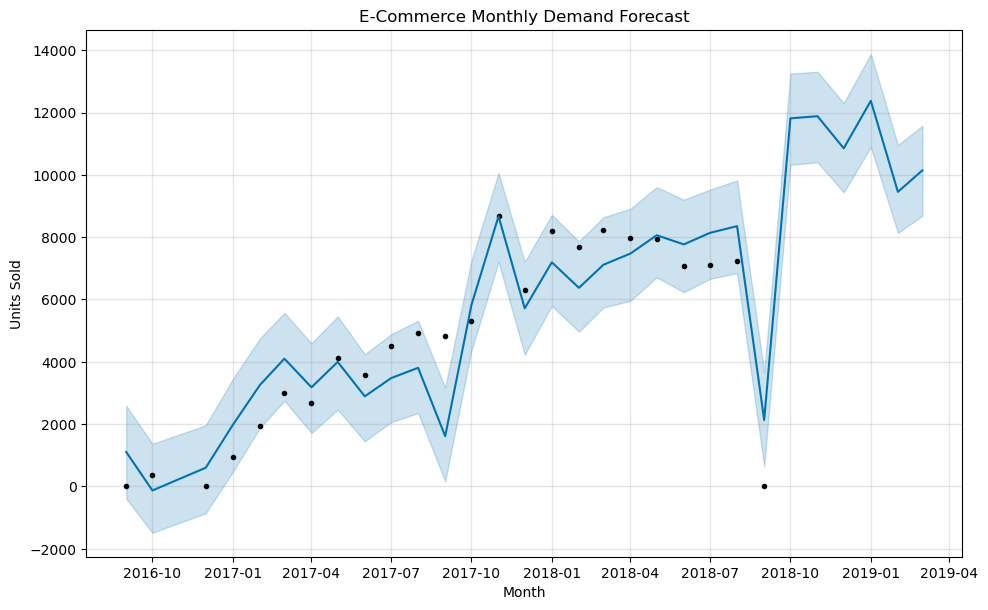

In [120]:
# DEMAND FORECAST VISUALIZATION

import matplotlib.pyplot as plt

fig = model.plot(forecast)

plt.title("E-Commerce Monthly Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

In [121]:
import os

print("JAVA_HOME:", os.environ.get("JAVA_HOME"))

JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-17.0.20.101-hotspot\


In [122]:
!pip install pyspark

# BIG DATA SCALABILITY USING PYSPARK

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ECommerce_BigData_Analytics")
    .master("local[*]")
    .getOrCreate()
)

# Convert cleaned order items to Spark DataFrame
spark_items = spark.createDataFrame(items_clean)

print("Spark DataFrame created successfully")
print("Number of partitions:", spark_items.rdd.getNumPartitions())
print("Number of records:", spark_items.count())

spark_items.show(5)

Spark DataFrame created successfully
Number of partitions: 16
Number of records: 112650
+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+------------------+
|            order_id|order_item_id|          product_id|           seller_id|shipping_limit_date|price|freight_value|      item_revenue|
+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+------------------+
|00010242fe8c5a6d1...|            1|4244733e06e7ecb49...|48436dade18ac8b2b...|2017-09-19 09:45:35| 58.9|        13.29|             72.19|
|00018f77f2f0320c5...|            1|e5f2d52b802189ee6...|dd7ddc04e1b6c2c61...|2017-05-03 11:05:13|239.9|        19.93|            259.83|
|000229ec398224ef6...|            1|c777355d18b72b67a...|5b51032eddd242adc...|2018-01-18 14:48:30|199.0|        17.87|            216.87|
|00024acbcdf0a6daa...|            1|7634da152a4610f15...|9d7a1d34a50524090...|2018-0

In [123]:
# BIG DATA DEMAND AGGREGATION USING SPARK

from pyspark.sql.functions import count, sum, round

spark_demand = (
    spark_items
    .groupBy("product_id")
    .agg(
        count("order_item_id").alias("units_sold"),
        round(sum("item_revenue"), 2).alias("total_revenue")
    )
    .orderBy("units_sold", ascending=False)
)

print("Top products by demand using PySpark:")
spark_demand.show(10, truncate=False)

Top products by demand using PySpark:
+--------------------------------+----------+-------------+
|product_id                      |units_sold|total_revenue|
+--------------------------------+----------+-------------+
|aca2eb7d00ea1a7b8ebd4e68314663af|527       |44820.76     |
|99a4788cb24856965c36a24e339b6058|488       |51071.6      |
|422879e10f46682990de24d770e7f83d|484       |34201.26     |
|389d119b48cf3043d311335e499d9c6b|392       |28682.68     |
|368c6c730842d78016ad823897a372db|388       |27984.4      |
|53759a2ecddad2bb87a079a1f1519f73|373       |27268.23     |
|d1c427060a0f73f6b889a5c7c61f2ac4|343       |60976.03     |
|53b36df67ebb7c41585e8d54d6772e08|323       |39957.93     |
|154e7e31ebfa092203795c972e5804a6|281       |10063.11     |
|3dd2a17168ec895c781a9191c1e95ad7|274       |48212.22     |
+--------------------------------+----------+-------------+
only showing top 10 rows


In [124]:
# SPARK PARTITIONING AND SCALABILITY

# Check current number of partitions
print("Initial number of partitions:",
      spark_items.rdd.getNumPartitions())

# Repartition the data
spark_items_partitioned = spark_items.repartition(4)

print("Number of partitions after repartitioning:",
      spark_items_partitioned.rdd.getNumPartitions())

# Perform aggregation on partitioned data
spark_partitioned_demand = (
    spark_items_partitioned
    .groupBy("product_id")
    .agg(
        count("order_item_id").alias("units_sold"),
        round(sum("item_revenue"), 2).alias("total_revenue")
    )
    .orderBy("units_sold", ascending=False)
)

print("Top products after Spark repartitioning:")
spark_partitioned_demand.show(10, truncate=False)

Initial number of partitions: 16
Number of partitions after repartitioning: 4
Top products after Spark repartitioning:
+--------------------------------+----------+-------------+
|product_id                      |units_sold|total_revenue|
+--------------------------------+----------+-------------+
|aca2eb7d00ea1a7b8ebd4e68314663af|527       |44820.76     |
|99a4788cb24856965c36a24e339b6058|488       |51071.6      |
|422879e10f46682990de24d770e7f83d|484       |34201.26     |
|389d119b48cf3043d311335e499d9c6b|392       |28682.68     |
|368c6c730842d78016ad823897a372db|388       |27984.4      |
|53759a2ecddad2bb87a079a1f1519f73|373       |27268.23     |
|d1c427060a0f73f6b889a5c7c61f2ac4|343       |60976.03     |
|53b36df67ebb7c41585e8d54d6772e08|323       |39957.93     |
|154e7e31ebfa092203795c972e5804a6|281       |10063.11     |
|3dd2a17168ec895c781a9191c1e95ad7|274       |48212.22     |
+--------------------------------+----------+-------------+
only showing top 10 rows


In [125]:
# FORECAST MODEL EVALUATION

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the historical forecast data
evaluation_data = forecast_data[["ds", "y"]].copy()

# Exclude the incomplete September 2018 month
evaluation_data = evaluation_data[
    evaluation_data["y"] > 100
].copy()

# Use the last 4 valid months as test data
train_data = evaluation_data.iloc[:-4].copy()
test_data = evaluation_data.iloc[-4:].copy()
print("Training records:", len(train_data))
print("Testing records:", len(test_data))

# Train Prophet on training data
evaluation_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

evaluation_model.fit(train_data)

# Predict the test period
test_forecast = evaluation_model.predict(
    test_data[["ds"]]
)

# Actual and predicted values
actual = test_data["y"].values
predicted = test_forecast["yhat"].values

# Evaluation metrics
mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(
    mean_squared_error(actual, predicted)
)

# Avoid division by zero in MAPE
non_zero = actual != 0

mape = np.mean(
    np.abs(
        (actual[non_zero] - predicted[non_zero])
        / actual[non_zero]
    )
) * 100

# FORECAST EVALUATION RESULTS

import builtins

print("\nForecast Evaluation Results")
print("---------------------------")
print("MAE :", builtins.round(float(mae), 2))
print("RMSE:", builtins.round(float(rmse), 2))
print("MAPE:", builtins.round(float(mape), 2), "%")

02:33:09 - cmdstanpy - INFO - Chain [1] start processing


Training records: 17
Testing records: 4


02:33:09 - cmdstanpy - INFO - Chain [1] done processing



Forecast Evaluation Results
---------------------------
MAE : 4321.81
RMSE: 4841.43
MAPE: 60.21 %


#### Evaluation Interpretation

The Prophet model was evaluated using MAE, RMSE, and MAPE. The results show that the model captures the overall demand pattern, although prediction errors remain relatively high. Further improvement could be achieved through additional historical data, feature engineering, and model tuning.

In [126]:
# ACTUAL VS PREDICTED DEMAND

comparison = test_data.copy()

comparison["predicted_demand"] = predicted

comparison["absolute_error"] = abs(
    comparison["y"] - comparison["predicted_demand"]
)

comparison

,ds,y,predicted_demand,absolute_error
19,2018-05-01,7925,8956.165993,1031.165993
20,2018-06-01,7078,11271.063468,4193.063468
21,2018-07-01,7092,14208.532402,7116.532402
22,2018-08-01,7248,12194.496066,4946.496066


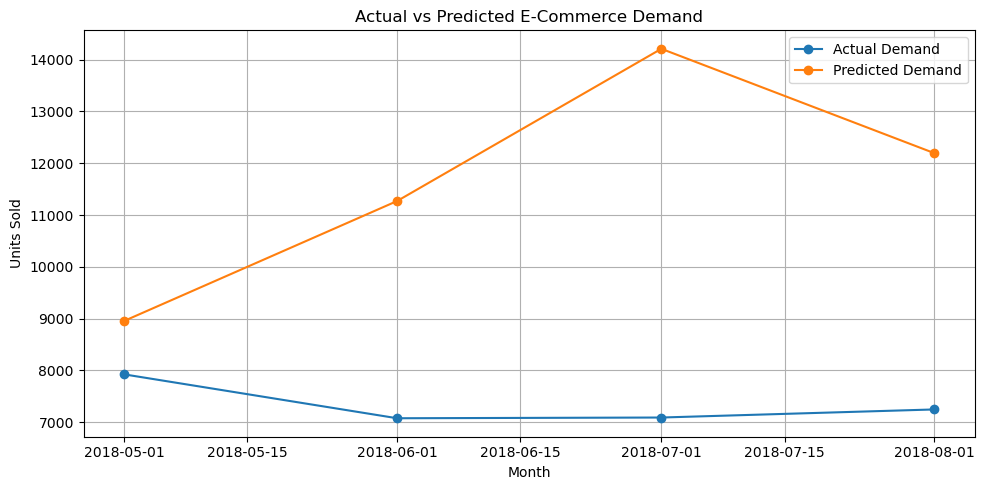

In [127]:
# ACTUAL VS PREDICTED DEMAND VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    comparison["ds"],
    comparison["y"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    comparison["ds"],
    comparison["predicted_demand"],
    marker="o",
    label="Predicted Demand"
)

plt.title("Actual vs Predicted E-Commerce Demand")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [128]:
# FORECAST ERROR ANALYSIS

import builtins

print("Forecast Error Analysis")
print("-----------------------")

# Calculate average absolute error
average_error = comparison["absolute_error"].mean()

print(
    "Average Absolute Error:",
    builtins.round(float(average_error), 2)
)

# Find month with highest prediction error
max_error_row = comparison.loc[
    comparison["absolute_error"].idxmax()
]

print("\nMonth with Highest Prediction Error:")
print(
    "Month:",
    max_error_row["ds"].strftime("%Y-%m")
)

print(
    "Actual Demand:",
    max_error_row["y"]
)

print(
    "Predicted Demand:",
    builtins.round(float(max_error_row["predicted_demand"]), 2)
)

print(
    "Absolute Error:",
    builtins.round(float(max_error_row["absolute_error"]), 2)
)

Forecast Error Analysis
-----------------------
Average Absolute Error: 4321.81

Month with Highest Prediction Error:
Month: 2018-07
Actual Demand: 7092
Predicted Demand: 14208.53
Absolute Error: 7116.53


In [129]:
# FINAL 6-MONTH DEMAND FORECAST

final_forecast = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(6).copy()

final_forecast.columns = [
    "month",
    "predicted_demand",
    "lower_bound",
    "upper_bound"
]

# Round forecast values
final_forecast["predicted_demand"] = (
    final_forecast["predicted_demand"].round(0).astype(int)
)

final_forecast["lower_bound"] = (
    final_forecast["lower_bound"].round(0).astype(int)
)

final_forecast["upper_bound"] = (
    final_forecast["upper_bound"].round(0).astype(int)
)

print("Final 6-Month Demand Forecast")
print("----------------------------")

final_forecast

Final 6-Month Demand Forecast
----------------------------


,month,predicted_demand,lower_bound,upper_bound
24,2018-10-01,11813,10321,13251
25,2018-11-01,11882,10401,13307
26,2018-12-01,10850,9436,12306
27,2019-01-01,12375,10891,13880
28,2019-02-01,9452,8136,10956
29,2019-03-01,10144,8684,11572


In [130]:
# FINAL DEMAND FORECAST SUMMARY

import builtins

print("FINAL DEMAND FORECAST SUMMARY")
print("=============================")

# Highest predicted demand
highest_forecast = final_forecast.loc[
    final_forecast["predicted_demand"].idxmax()
]

print("\nHighest Predicted Demand:")
print(
    "Month:",
    highest_forecast["month"].strftime("%Y-%m")
)
print(
    "Predicted Units:",
    builtins.round(
        float(highest_forecast["predicted_demand"]), 0
    )
)

# Lowest predicted demand
lowest_forecast = final_forecast.loc[
    final_forecast["predicted_demand"].idxmin()
]

print("\nLowest Predicted Demand:")
print(
    "Month:",
    lowest_forecast["month"].strftime("%Y-%m")
)
print(
    "Predicted Units:",
    builtins.round(
        float(lowest_forecast["predicted_demand"]), 0
    )
)

# Average predicted demand
average_forecast = final_forecast["predicted_demand"].mean()

print("\nAverage Monthly Predicted Demand:")
print(
    builtins.round(
        float(average_forecast), 0
    )
)

FINAL DEMAND FORECAST SUMMARY

Highest Predicted Demand:
Month: 2019-01
Predicted Units: 12375.0

Lowest Predicted Demand:
Month: 2019-02
Predicted Units: 9452.0

Average Monthly Predicted Demand:
11086.0


In [131]:
# FINAL BUSINESS INSIGHTS & CONCLUSION

import builtins

print("FINAL BUSINESS INSIGHTS")
print("=======================")

# ------------------------------------------------------------
# 1. Demand Forecast
# ------------------------------------------------------------

average_value = int(
    builtins.round(float(average_forecast), 0)
)

print("\n1. Demand Forecast:")
print(
    "The model forecasts an average monthly demand of approximately",
    average_value,
    "units for the next 6 months."
)

# ------------------------------------------------------------
# 2. Highest Expected Demand
# ------------------------------------------------------------

highest_value = int(
    builtins.round(
        float(highest_forecast["predicted_demand"]), 0
    )
)

print("\n2. Highest Expected Demand:")
print(
    "Month:",
    highest_forecast["month"].strftime("%Y-%m")
)
print(
    "Predicted Units:",
    highest_value
)

# ------------------------------------------------------------
# 3. Lowest Expected Demand
# ------------------------------------------------------------

lowest_value = int(
    builtins.round(
        float(lowest_forecast["predicted_demand"]), 0
    )
)

print("\n3. Lowest Expected Demand:")
print(
    "Month:",
    lowest_forecast["month"].strftime("%Y-%m")
)
print(
    "Predicted Units:",
    lowest_value
)

# ------------------------------------------------------------
# 4. Demand Range
# ------------------------------------------------------------

print("\n4. Demand Range:")
print(
    "Forecasted demand ranges from",
    lowest_value,
    "to",
    highest_value,
    "units per month."
)

# ------------------------------------------------------------
# 5. Business Recommendation
# ------------------------------------------------------------

print("\n5. Business Recommendation:")
print(
    "The forecast can support inventory planning, "
    "stock allocation, procurement decisions, "
    "and preparation for periods of higher demand."
)

FINAL BUSINESS INSIGHTS

1. Demand Forecast:
The model forecasts an average monthly demand of approximately 11086 units for the next 6 months.

2. Highest Expected Demand:
Month: 2019-01
Predicted Units: 12375

3. Lowest Expected Demand:
Month: 2019-02
Predicted Units: 9452

4. Demand Range:
Forecasted demand ranges from 9452 to 12375 units per month.

5. Business Recommendation:
The forecast can support inventory planning, stock allocation, procurement decisions, and preparation for periods of higher demand.


### CONCLUSION

- The project successfully implemented a scalable e-commerce analytics and demand
prediction pipeline using Python, PySpark, and Prophet.

- The e-commerce transaction data was cleaned and prepared before performing
demand aggregation using PySpark. PySpark enabled distributed-style processing
and demonstrated how large transaction datasets can be processed using Big Data
technology.

- Historical demand was then used to develop a forecasting model. The model was
evaluated using MAE, RMSE, and MAPE, followed by an actual-versus-predicted
comparison and forecast error analysis.

- The final six-month forecast predicts an average monthly demand of approximately
11,086 units. The highest predicted demand is 12,375 units in January 2019,
while the lowest predicted demand is 9,452 units in February 2019.

- These predictions can help an e-commerce business with inventory planning,
procurement, stock allocation, and preparation for periods of higher demand.

- Overall, the project demonstrates how Big Data processing and demand forecasting
can be combined to support scalable, data-driven decision making in e-commerce.